In [1]:
!pip install transformers datasets accelerate trl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 697.4/697.4 kB 32.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 14.9 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0


In [4]:
from env import TaskEnv

env = TaskEnv()

state = env.reset()
print("Initial state:", state)

TypeError: TaskEnv.__init__() missing 1 required positional argument: 'tasks'

In [5]:
tasks = [
    {"priority": 3, "duration": 2},
    {"priority": 1, "duration": 5},
    {"priority": 2, "duration": 1}
]

In [6]:
from env import TaskEnv

env = TaskEnv(tasks)

state = env.reset()
print("Initial state:", state)

Initial state: [{'priority': 3, 'duration': 2}, {'priority': 1, 'duration': 5}, {'priority': 2, 'duration': 1}]


In [7]:
def state_to_prompt(state):
    prompt = "You are a task scheduler.\n\nTasks:\n"

    for i, task in enumerate(state):
        prompt += f"{i}: priority={task['priority']}, duration={task['duration']}\n"

    prompt += "\nChoose the task index to execute next:\n"

    return prompt

In [8]:
def response_to_action(response):
    import re

    numbers = re.findall(r"\d+", response)

    if len(numbers) > 0:
        return int(numbers[0])

    return 0  # fallback

In [9]:
from transformers import AutoTokenizer, AutoModelForCausalLM

In [10]:
get_model_response()

NameError: name 'get_model_response' is not defined

In [11]:
from transformers import AutoTokenizer, AutoModelForCausalLM

model_name = "distilgpt2"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

In [12]:
def get_model_response(prompt):
    inputs = tokenizer(prompt, return_tensors="pt")

    outputs = model.generate(
        **inputs,
        max_new_tokens=5,
        pad_token_id=tokenizer.eos_token_id
    )

    text = tokenizer.decode(outputs[0], skip_special_tokens=True)

    return text[len(prompt):]

In [13]:
state = env.reset()
done = False
steps = 0

while not done and steps < 10:
    prompt = state_to_prompt(state)

    print("PROMPT:\n", prompt)

    response = get_model_response(prompt)
    action = response_to_action(response)

    # safety clamp
    action = min(action, len(state)-1)

    state, reward, done, _ = env.step(action)

    print("MODEL RESPONSE:", response)
    print("ACTION:", action, "| REWARD:", reward)
    print("------------")

    steps += 1

PROMPT:
 You are a task scheduler.

Tasks:
0: priority=3, duration=2
1: priority=1, duration=5
2: priority=2, duration=1

Choose the task index to execute next:



KeyError: 'id'

In [14]:
tasks = [
    {"id": 0, "priority": 3, "duration": 2},
    {"id": 1, "priority": 1, "duration": 5},
    {"id": 2, "priority": 2, "duration": 1}
]

In [16]:
env = TaskEnv(tasks)

In [18]:
state = env.reset()
done = False
steps = 0

while not done and steps < 10:
    prompt = state_to_prompt(state)

    print("PROMPT:\n", prompt)

    response = get_model_response(prompt)
    action = response_to_action(response)

    action = min(action, len(state)-1)

    state, reward, done = env.step(action)

    print("MODEL RESPONSE:", response)
    print("ACTION:", action, "| REWARD:", reward)
    print("------------")

    steps += 1

PROMPT:
 You are a task scheduler.

Tasks:
0: priority=3, duration=2
1: priority=1, duration=5
2: priority=2, duration=1

Choose the task index to execute next:

MODEL RESPONSE: 1: priority=1
ACTION: 1 | REWARD: 1.0
------------
PROMPT:
 You are a task scheduler.

Tasks:
0: priority=3, duration=2
1: priority=2, duration=1

Choose the task index to execute next:

MODEL RESPONSE: 1: priority=3
ACTION: 1 | REWARD: 3.5
------------
PROMPT:
 You are a task scheduler.

Tasks:
0: priority=3, duration=2

Choose the task index to execute next:

MODEL RESPONSE: 1: priority=3
ACTION: 0 | REWARD: 4.4
------------


In [19]:
from trl import PPOTrainer, PPOConfig

ImportError: cannot import name 'PPOTrainer' from 'trl' (/usr/local/lib/python3.12/dist-packages/trl/__init__.py)

In [20]:
!pip install trl==0.7.10

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.9/150.9 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.2/185.2 kB 6.3 MB/s eta 0:00:00
  Attempting uninstall: trl
    Found existing installation: trl 1.2.0
    Uninstalling trl-1.2.0:
      Successfully uninstalled trl-1.2.0


In [1]:
!pip install trl==0.7.10

In [2]:
from transformers import AutoTokenizer, AutoModelForCausalLM
from env import TaskEnv
from trl import PPOTrainer, PPOConfig

ImportError: cannot import name 'top_k_top_p_filtering' from 'transformers' (/usr/local/lib/python3.12/dist-packages/transformers/__init__.py)

In [1]:
!pip install transformers==4.31.0 trl==0.7.10 accelerate==0.21.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.9/116.9 kB 4.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 314.9/314.9 kB 14.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 76.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 244.2/244.2 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 31.3 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × Building wheel for tokenizers (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for tokenizers
Failed to build tokenizers
ERROR: ERROR: Failed to build installable wheels for some pyproject.toml based projects (tokenizers)


In [15]:
!pip uninstall -y trl transformers accelerate datasets
!pip install trl transformers accelerate datasets --quiet

from transformers import AutoTokenizer, AutoModelForCausalLM
from env import TaskEnv
from trl.trainer.ppo_config import PPOConfig
from trl.trainer.ppo_trainer import PPOTrainer

ModuleNotFoundError: No module named 'trl.trainer.ppo_config'

In [17]:
!pip install transformers==4.31.0 trl==0.7.10 accelerate==0.21.0

  Using cached transformers-4.31.0-py3-none-any.whl.metadata (116 kB)
  Using cached trl-0.7.10-py3-none-any.whl.metadata (10 kB)
  Using cached accelerate-0.21.0-py3-none-any.whl.metadata (17 kB)
  Using cached huggingface_hub-0.36.2-py3-none-any.whl.metadata (15 kB)
  Using cached tokenizers-0.13.3.tar.gz (314 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Using cached transformers-4.31.0-py3-none-any.whl (7.4 MB)
Using cached trl-0.7.10-py3-none-any.whl (150 kB)
Using cached accelerate-0.21.0-py3-none-any.whl (244 kB)
Using cached huggingface_hub-0.36.2-py3-none-any.whl (566 kB)
  error: subprocess-exited-with-error
  
  × Building wheel for tokenizers (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> No available output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for tokenizers
Failed to build token

In [19]:
import torch

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)

for episode in range(10):
    state = env.reset()
    done = False
    total_reward = 0

    while not done:
        prompt = state_to_prompt(state)

        inputs = tokenizer(prompt, return_tensors="pt")

        outputs = model.generate(
            **inputs,
            max_new_tokens=5,
            pad_token_id=tokenizer.eos_token_id
        )

        full_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
        response = full_text[len(prompt):]

        action = response_to_action(response)
        action = min(action, len(state)-1)

        next_state, reward, done = env.step(action)

        # 🔥 simple reward signal
        loss = torch.tensor(-reward, requires_grad=True)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_reward += reward
        state = next_state

    print(f"Episode {episode} | Total Reward: {total_reward}")


NameError: name 'model' is not defined

In [20]:
from transformers import AutoTokenizer, AutoModelForCausalLM

model_name = "distilgpt2"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
You are using a model of type gpt2 to instantiate a model of type . This is not supported for all configurations of models and can yield errors.


StrictDataclassDefinitionError: Class 'GPT2Config' must be a dataclass before applying @strict.

In [1]:
!pip install transformers==4.35.2 torch==2.2.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.5/123.5 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.5/755.5 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 72.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 56.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 42.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 623.7 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
from transformers import AutoTokenizer, AutoModelForCausalLM

model_name = "distilgpt2"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)

print("Model loaded successfully")


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py", line 37, in <module>
    ColabKernelApp.launch_instance()
  File "/usr/local/lib/python3.12/dist-packages/traitlets/config/application.py", line 992, in launch_instance
    app.start()
  File "/usr/local/lib/python3.12/dist-packages/ipykernel/kernelapp.py", line 712, in start
    self.io_loop.start()
  File "/usr/local/lib/python3.12/dist-package

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:309: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  _torch_pytree._register_pytree_node(
/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:309: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  _torch_pytree._register_pytree_node(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Model loaded successfully


In [3]:
import torch

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)

for episode in range(10):
    state = env.reset()
    done = False
    total_reward = 0

    while not done:
        prompt = state_to_prompt(state)

        inputs = tokenizer(prompt, return_tensors="pt")

        outputs = model.generate(
            **inputs,
            max_new_tokens=5,
            pad_token_id=tokenizer.eos_token_id
        )

        full_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
        response = full_text[len(prompt):]

        action = response_to_action(response)
        action = min(action, len(state)-1)

        next_state, reward, done = env.step(action)

        # simple reward learning
        loss = torch.tensor(-reward, requires_grad=True)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_reward += reward
        state = next_state

    print(f"Episode {episode} | Total Reward: {total_reward}")

NameError: name 'env' is not defined

In [4]:
from env import TaskEnv

tasks = [
    {"id": 0, "priority": 3, "duration": 2},
    {"id": 1, "priority": 1, "duration": 5},
    {"id": 2, "priority": 2, "duration": 1}
]

env = TaskEnv(tasks)

ModuleNotFoundError: No module named 'env'

In [5]:
from env import TaskEnv

tasks = [
    {"id": 0, "priority": 3, "duration": 2},
    {"id": 1, "priority": 1, "duration": 5},
    {"id": 2, "priority": 2, "duration": 1}
]

env = TaskEnv(tasks)

In [6]:
import torch

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)

for episode in range(10):
    state = env.reset()
    done = False
    total_reward = 0

    while not done:
        prompt = state_to_prompt(state)

        inputs = tokenizer(prompt, return_tensors="pt")

        outputs = model.generate(
            **inputs,
            max_new_tokens=5,
            pad_token_id=tokenizer.eos_token_id
        )

        full_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
        response = full_text[len(prompt):]

        action = response_to_action(response)
        action = min(action, len(state)-1)

        next_state, reward, done = env.step(action)

        loss = torch.tensor(-reward, requires_grad=True)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_reward += reward
        state = next_state

    print(f"Episode {episode} | Total Reward: {total_reward}")

NameError: name 'state_to_prompt' is not defined

In [7]:
def state_to_prompt(state):
    prompt = "You are a task scheduler.\n\nTasks:\n"

    for i, task in enumerate(state):
        prompt += f"{i}: priority={task['priority']}, duration={task['duration']}\n"

    prompt += "\nChoose the task index to execute next:\n"

    return prompt

In [8]:
def response_to_action(response):
    import re

    numbers = re.findall(r"\d+", response)

    if numbers:
        return int(numbers[0])

    return 0

In [10]:
import torch

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)

for episode in range(10):
    state = env.reset()
    done = False
    total_reward = 0

    while not done:
        prompt = state_to_prompt(state)

        inputs = tokenizer(prompt, return_tensors="pt")

        outputs = model.generate(
            **inputs,
            max_new_tokens=5,
            pad_token_id=tokenizer.eos_token_id
        )

        full_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
        response = full_text[len(prompt):]

        action = response_to_action(response)
        action = min(action, len(state)-1)

        next_state, reward, done = env.step(action)

        logits = model(**inputs).logits

        # take last token prediction
        log_probs = torch.nn.functional.log_softmax(logits[:, -1, :], dim=-1)

        # pick the token the model generated (approx)
        chosen_token = outputs[0][-1]

        log_prob = log_probs[0, chosen_token]

        # policy gradient style loss
        loss = -reward * log_prob

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_reward += reward
        state = next_state

    print(f"Episode {episode} | Total Reward: {total_reward}")

Episode 0 | Total Reward: 8.9
Episode 1 | Total Reward: 8.9
Episode 2 | Total Reward: 8.9
Episode 3 | Total Reward: 7.300000000000001
Episode 4 | Total Reward: 7.300000000000001
Episode 5 | Total Reward: 7.300000000000001
Episode 6 | Total Reward: 7.300000000000001
Episode 7 | Total Reward: 7.300000000000001
Episode 8 | Total Reward: 7.300000000000001
Episode 9 | Total Reward: 7.300000000000001


In [11]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)

rewards_history = []

for episode in range(30):  # more episodes = better signal
    state = env.reset()
    done = False
    total_reward = 0

    while not done:
        prompt = state_to_prompt(state)

        inputs = tokenizer(prompt, return_tensors="pt")

        # 🔥 enable exploration
        outputs = model.generate(
            **inputs,
            max_new_tokens=5,
            do_sample=True,
            temperature=1.0,
            pad_token_id=tokenizer.eos_token_id
        )

        full_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
        response = full_text[len(prompt):]

        action = response_to_action(response)
        action = min(action, len(state)-1)

        next_state, reward, done = env.step(action)

        # 🔥 compute log prob of chosen token
        logits = model(**inputs).logits
        log_probs = F.log_softmax(logits[:, -1, :], dim=-1)

        chosen_token = outputs[0][-1]
        log_prob = log_probs[0, chosen_token]

        # 🔥 normalize reward (important for stability)
        normalized_reward = reward / 10.0

        # 🔥 policy gradient loss
        loss = -normalized_reward * log_prob

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_reward += reward
        state = next_state

    rewards_history.append(total_reward)

    print(f"Episode {episode} | Total Reward: {total_reward}")

Episode 0 | Total Reward: 7.300000000000001
Episode 1 | Total Reward: 7.300000000000001
Episode 2 | Total Reward: 7.300000000000001
Episode 3 | Total Reward: 7.300000000000001
Episode 4 | Total Reward: 7.300000000000001
Episode 5 | Total Reward: 7.300000000000001
Episode 6 | Total Reward: 7.300000000000001
Episode 7 | Total Reward: 7.300000000000001
Episode 8 | Total Reward: 7.300000000000001
Episode 9 | Total Reward: 7.300000000000001
Episode 10 | Total Reward: 7.300000000000001
Episode 11 | Total Reward: 7.300000000000001
Episode 12 | Total Reward: 7.300000000000001
Episode 13 | Total Reward: 7.300000000000001
Episode 14 | Total Reward: 7.300000000000001


KeyboardInterrupt: 

In [12]:
import random

def generate_tasks():
    return [
        {"id": i, "priority": random.randint(1, 5), "duration": random.randint(1, 5)}
        for i in range(3)
    ]

In [13]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)

rewards_history = []

for episode in range(30):

    # 🔥 NEW: random tasks each episode
    tasks = generate_tasks()
    env = TaskEnv(tasks)

    state = env.reset()
    done = False
    total_reward = 0

    while not done:
        prompt = state_to_prompt(state)

        inputs = tokenizer(prompt, return_tensors="pt")

        outputs = model.generate(
            **inputs,
            max_new_tokens=5,
            do_sample=True,
            temperature=1.0,
            pad_token_id=tokenizer.eos_token_id
        )

        full_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
        response = full_text[len(prompt):]

        action = response_to_action(response)
        action = min(action, len(state)-1)

        next_state, reward, done = env.step(action)

        # 🔥 learning signal
        logits = model(**inputs).logits
        log_probs = F.log_softmax(logits[:, -1, :], dim=-1)

        chosen_token = outputs[0][-1]
        log_prob = log_probs[0, chosen_token]

        normalized_reward = reward / 10.0
        loss = -normalized_reward * log_prob

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_reward += reward
        state = next_state

    rewards_history.append(total_reward)

    print(f"Episode {episode} | Total Reward: {total_reward}")

Episode 0 | Total Reward: 11.0
Episode 1 | Total Reward: 13.4
Episode 2 | Total Reward: 9.899999999999999
Episode 3 | Total Reward: 12.3
Episode 4 | Total Reward: 11.5
Episode 5 | Total Reward: 13.8
Episode 6 | Total Reward: 9.7
Episode 7 | Total Reward: 12.3
Episode 8 | Total Reward: 11.3
Episode 9 | Total Reward: 11.3
Episode 10 | Total Reward: 9.399999999999999
Episode 11 | Total Reward: 6.0


KeyboardInterrupt: 

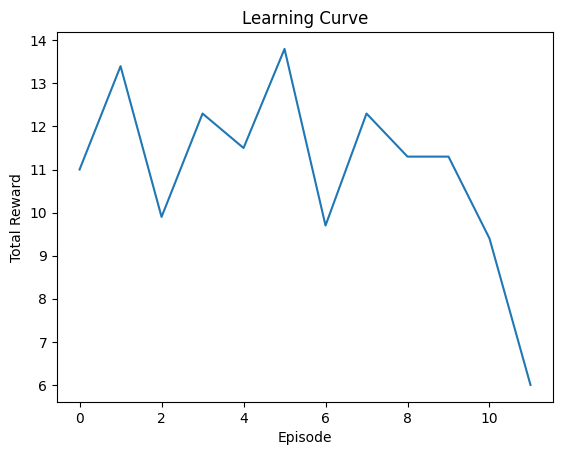

In [14]:
plt.plot(rewards_history)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Learning Curve")
plt.show()

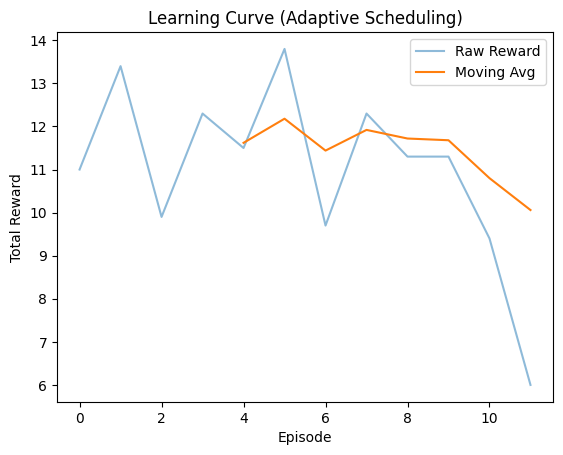

In [15]:
import numpy as np
import matplotlib.pyplot as plt

rewards = rewards_history
window = 5

moving_avg = np.convolve(rewards, np.ones(window)/window, mode='valid')

plt.plot(rewards, alpha=0.5, label="Raw Reward")
plt.plot(range(window-1, len(rewards)), moving_avg, label="Moving Avg")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Learning Curve (Adaptive Scheduling)")
plt.legend()
plt.show()

In [16]:
import random

def random_policy_run():
    tasks = generate_tasks()
    env = TaskEnv(tasks)

    state = env.reset()
    done = False
    total_reward = 0

    while not done:
        action = random.randint(0, len(state)-1)
        state, reward, done = env.step(action)
        total_reward += reward

    return total_reward


baseline_rewards = [random_policy_run() for _ in range(30)]

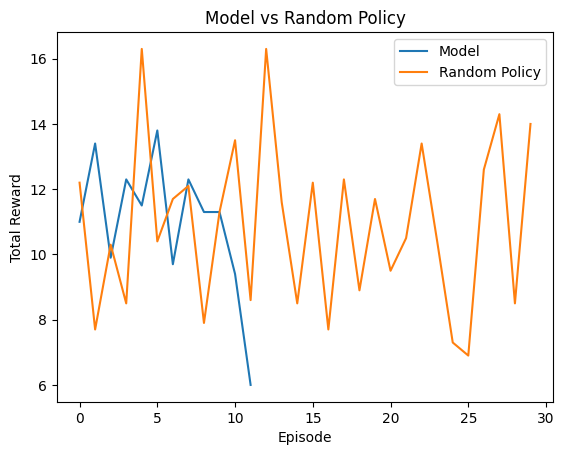

Model Avg: 10.991666666666665
Random Avg: 10.903333333333334


In [20]:
plt.plot(rewards_history, label="Model")
plt.plot(baseline_rewards, label="Random Policy")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Model vs Random Policy")
plt.legend()
plt.show()
import numpy as np

print("Model Avg:", np.mean(rewards_history))
print("Random Avg:", np.mean(baseline_rewards))

In [18]:
import numpy as np

print("Model Avg:", np.mean(rewards_history))
print("Random Avg:", np.mean(baseline_rewards))

Model Avg: 10.991666666666665
Random Avg: 10.903333333333334


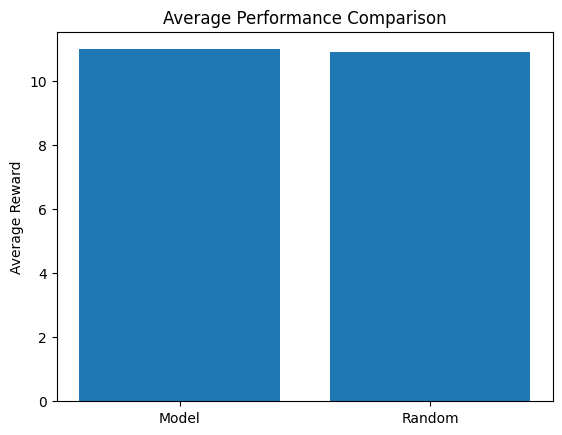

In [21]:
plt.bar(["Model", "Random"], [np.mean(rewards_history), np.mean(baseline_rewards)])
plt.ylabel("Average Reward")
plt.title("Average Performance Comparison")
plt.show()